# Final Model Evaluation and Comparison

## Part 8 – Comparing All Forecasting Approaches

This notebook brings together the forecasting results from all modelling approaches developed during the analysis.

The models are evaluated using common accuracy metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R²

The models are also compared visually using forecast plots.

The purpose of this analysis is not only to identify the model with the lowest numerical error, but also to assess:

- Forecast accuracy
- Ability to capture appliance consumption patterns
- Model complexity
- Interpretability
- Computational requirements
- Availability of predictor variables at the forecast origin
- Practical suitability for smart-home energy forecasting

The final recommendation will therefore consider both predictive performance and practical deployment considerations.

# 2. Import Required Libraries

The required libraries are imported for loading saved model results, calculating additional metrics, creating comparison tables and visualising forecasts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 3. Loading Saved Model Results

The evaluation results generated in the previous modelling notebooks are loaded from CSV files.

Saving and loading intermediate results avoids unnecessary model retraining and ensures that the final comparison is reproducible.

In [2]:
xgb_results = pd.read_csv(
    "../outputs/tables/xgboost_results.csv"
)

chronos_results = pd.read_csv(
    "../outputs/tables/chronos_results.csv"
)

print("XGBoost results:")
display(xgb_results)

print("\nChronos results:")
display(chronos_results)

XGBoost results:


,Model,MAE,RMSE,MAPE,R2
0,XGBoost,42.741712,51.439934,45.151047,-0.08764



Chronos results:


,Model,MAE,RMSE,MAPE,R2
0,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422


# 4. Loading SARIMA and SARIMAX Results

The SARIMA and SARIMAX forecasting results generated in the previous modelling stages are loaded for final comparison.

The `sarima_results.csv` file contains the standalone SARIMA evaluation, while `sarima_vs_sarimax.csv` contains a direct comparison between SARIMA and SARIMAX using the same evaluation framework.

For the final model comparison, the SARIMA and SARIMAX results from `sarima_vs_sarimax.csv` are used because both models were evaluated together over the same forecasting period.

The models are compared using MAE, RMSE, MAPE and R².

In [3]:
sarima_results = pd.read_csv(
    "../outputs/tables/sarima_results.csv"
)

sarima_vs_sarimax = pd.read_csv(
    "../outputs/tables/sarima_vs_sarimax.csv"
)

print("SARIMA Results:")
display(sarima_results)

print("\nSARIMA vs SARIMAX Results:")
display(sarima_vs_sarimax)

SARIMA Results:


,Model,MAE,RMSE,MAPE,R2
0,SARIMA,18.932311,26.808493,19.742237,0.704587



SARIMA vs SARIMAX Results:


,Model,MAE,RMSE,MAPE,R2
0,SARIMA,18.621049,25.780928,19.060398,0.726799
1,SARIMAX,298.516440,323.181340,361.334188,-41.931595


# 5. Final Model Performance Comparison

The performance of the statistical and machine-learning models is compared using a common set of forecasting metrics.

The main metrics are:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R²

Lower MAE, RMSE and MAPE indicate lower forecasting error, while a higher R² indicates better explanatory performance.

The SARIMA and SARIMAX results are taken from the direct SARIMA-versus-SARIMAX comparison to ensure that both models are evaluated over the same forecasting period.

In [4]:
# Extract SARIMA and SARIMAX results

sarima_final = sarima_vs_sarimax[
    sarima_vs_sarimax["Model"] == "SARIMA"
].copy()

sarimax_final = sarima_vs_sarimax[
    sarima_vs_sarimax["Model"] == "SARIMAX"
].copy()


# Combine with XGBoost and Chronos

final_results = pd.concat(
    [
        sarima_final,
        sarimax_final,
        xgb_results,
        chronos_results
    ],
    ignore_index=True
)


final_results

,Model,MAE,RMSE,MAPE,R2
0,SARIMA,18.621049,25.780928,19.060398,0.726799
1,SARIMAX,298.516440,323.181340,361.334188,-41.931595
2,XGBoost,42.741712,51.439934,45.151047,-0.087640
3,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422


# 6. Loading Benchmark Forecast Results

The benchmark forecasting models provide simple reference points against which the more complex forecasting approaches can be evaluated.

The benchmark models considered in Part 3 include:

- Mean forecast
- Naive forecast
- Daily seasonal naive forecast
- Weekly seasonal naive forecast
- Drift forecast

These models are important because a complex model should demonstrate a meaningful improvement over appropriate simple forecasting strategies before its additional complexity can be justified.

The previously generated benchmark evaluation results are loaded from `benchmark_results.csv`.

In [5]:
benchmark_results = pd.read_csv(
    "../outputs/tables/benchmark_results.csv"
)

display(benchmark_results)

,Model,MAE,RMSE,MAPE,R2
0,Mean,50.258092,74.938304,53.695620,-0.002597
1,Naive,85.550595,110.389709,112.910665,-1.175584
2,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
3,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
4,Drift,85.802089,110.679190,113.309050,-1.187009


In [6]:
print("Benchmark columns:")
print(benchmark_results.columns.tolist())

Benchmark columns:
['Model', 'MAE', 'RMSE', 'MAPE', 'R2']


In [7]:
print("Benchmark models:")
print(benchmark_results["Model"].tolist())

Benchmark models:
['Mean', 'Naive', 'Daily Seasonal Naive', 'Weekly Seasonal Naive', 'Drift']


# 7. Combining All Model Results

The results from all forecasting approaches are combined into a single evaluation table.

The models include:

- Mean
- Naive
- Daily Seasonal Naive
- Weekly Seasonal Naive
- Drift
- SARIMA
- SARIMAX
- XGBoost
- Chronos-T5

All models are evaluated using the same four performance metrics:

- MAE
- RMSE
- MAPE
- R²

This allows the forecasting approaches to be compared consistently and provides the basis for selecting the strongest model.

In [8]:
# Select SARIMA and SARIMAX from the direct comparison
sarima_final = sarima_vs_sarimax[
    sarima_vs_sarimax["Model"] == "SARIMA"
].copy()

sarimax_final = sarima_vs_sarimax[
    sarima_vs_sarimax["Model"] == "SARIMAX"
].copy()


# Combine all model results
final_results = pd.concat(
    [
        benchmark_results,
        sarima_final,
        sarimax_final,
        xgb_results,
        chronos_results
    ],
    ignore_index=True
)


# Display results
display(final_results)

,Model,MAE,RMSE,MAPE,R2
0,Mean,50.258092,74.938304,53.695620,-0.002597
1,Naive,85.550595,110.389709,112.910665,-1.175584
2,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
3,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
4,Drift,85.802089,110.679190,113.309050,-1.187009
5,SARIMA,18.621049,25.780928,19.060398,0.726799
6,SARIMAX,298.516440,323.181340,361.334188,-41.931595
7,XGBoost,42.741712,51.439934,45.151047,-0.087640
8,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422


# 8. Checking the Final Evaluation Table

Before performing the final analysis, the combined results are checked to ensure that every model has the required evaluation metrics.

The resulting table should contain one row for each forecasting model and the following columns:

- Model
- MAE
- RMSE
- MAPE
- R²

This table will form the main quantitative comparison used in the final report.

In [9]:
print("Shape of final results:", final_results.shape)

print("\nColumns:")
print(final_results.columns.tolist())

print("\nMissing values:")
display(final_results.isnull().sum())

display(final_results)

Shape of final results: (9, 5)

Columns:
['Model', 'MAE', 'RMSE', 'MAPE', 'R2']

Missing values:


Model    0
MAE      0
RMSE     0
MAPE     0
R2       0
dtype: int64

,Model,MAE,RMSE,MAPE,R2
0,Mean,50.258092,74.938304,53.695620,-0.002597
1,Naive,85.550595,110.389709,112.910665,-1.175584
2,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
3,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
4,Drift,85.802089,110.679190,113.309050,-1.187009
5,SARIMA,18.621049,25.780928,19.060398,0.726799
6,SARIMAX,298.516440,323.181340,361.334188,-41.931595
7,XGBoost,42.741712,51.439934,45.151047,-0.087640
8,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422


# 9. Ranking Models by Forecast Accuracy

The models are ranked according to their RMSE.

RMSE measures the average magnitude of forecasting errors while giving greater weight to larger errors.

A lower RMSE therefore indicates better forecasting performance.

The ranking is used as one component of the final model selection, alongside MAE, MAPE, R², interpretability, computational cost and deployment considerations.

In [10]:
ranking_rmse = final_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)


ranking_rmse.insert(
    0,
    "Rank",
    range(1, len(ranking_rmse) + 1)
)


display(ranking_rmse)

,Rank,Model,MAE,RMSE,MAPE,R2
0,1,SARIMA,18.621049,25.780928,19.060398,0.726799
1,2,XGBoost,42.741712,51.439934,45.151047,-0.087640
2,3,Mean,50.258092,74.938304,53.695620,-0.002597
3,4,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
4,5,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
5,6,Naive,85.550595,110.389709,112.910665,-1.175584
6,7,Drift,85.802089,110.679190,113.309050,-1.187009
7,8,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422
8,9,SARIMAX,298.516440,323.181340,361.334188,-41.931595


# 10. Ranking Models by MAE

The models are additionally ranked using Mean Absolute Error (MAE).

MAE represents the average absolute difference between the predicted and observed appliance energy consumption.

Unlike RMSE, MAE does not give additional weight to large errors, making it easier to interpret as the typical forecasting error.

In [11]:
ranking_mae = final_results.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)


ranking_mae.insert(
    0,
    "Rank",
    range(1, len(ranking_mae) + 1)
)


display(ranking_mae)

,Rank,Model,MAE,RMSE,MAPE,R2
0,1,SARIMA,18.621049,25.780928,19.060398,0.726799
1,2,XGBoost,42.741712,51.439934,45.151047,-0.087640
2,3,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
3,4,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
4,5,Mean,50.258092,74.938304,53.695620,-0.002597
5,6,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422
6,7,Naive,85.550595,110.389709,112.910665,-1.175584
7,8,Drift,85.802089,110.679190,113.309050,-1.187009
8,9,SARIMAX,298.516440,323.181340,361.334188,-41.931595


# 11. Saving the Final Model Comparison

The complete model comparison is saved as a CSV file.

Saving the results ensures that the numerical values used in the report can be reproduced without rerunning the forecasting models.

In [12]:
final_results.to_csv(
    "../outputs/tables/final_model_comparison.csv",
    index=False
)

ranking_rmse.to_csv(
    "../outputs/tables/model_ranking_rmse.csv",
    index=False
)

print("Final comparison results saved successfully.")

Final comparison results saved successfully.


# 12. Comparing Model Performance

The RMSE values of all forecasting models are visualised using a bar chart.

RMSE is selected for the primary visual comparison because it penalises large forecasting errors, which is important for energy demand forecasting where substantial prediction errors can be operationally significant.

Lower values represent better forecasting performance.

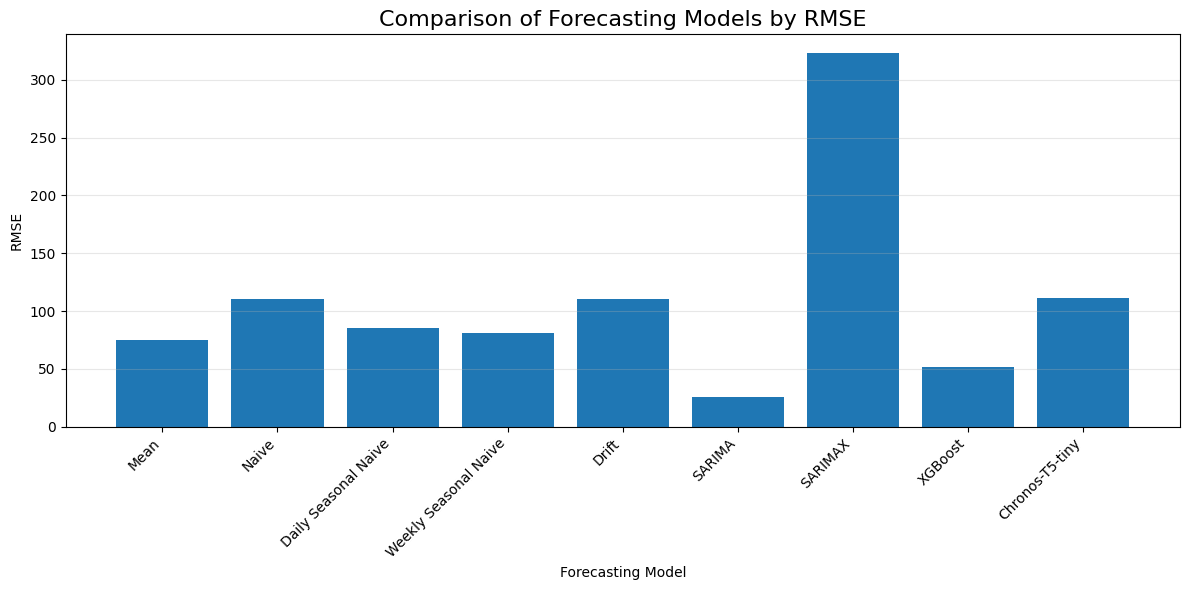

In [13]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["RMSE"]
)

plt.title(
    "Comparison of Forecasting Models by RMSE",
    fontsize=16
)

plt.xlabel("Forecasting Model")
plt.ylabel("RMSE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 13. Comparison of Mean Absolute Error

MAE is visualised to provide a second perspective on forecasting accuracy.

While RMSE emphasises large errors, MAE represents the typical absolute forecasting error and is therefore useful for understanding the practical magnitude of prediction errors.

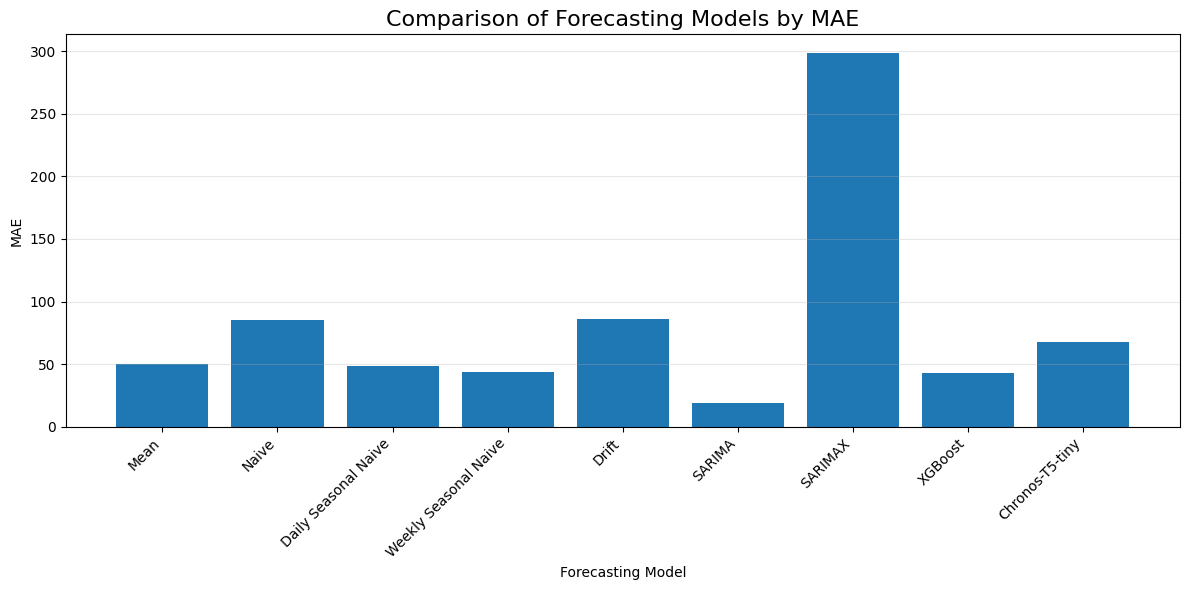

In [14]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["MAE"]
)

plt.title(
    "Comparison of Forecasting Models by MAE",
    fontsize=16
)

plt.xlabel("Forecasting Model")
plt.ylabel("MAE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 14. Final Model Ranking

The forecasting models are ranked according to RMSE, with lower values indicating better predictive accuracy.

SARIMA achieves the lowest RMSE of 25.78 and the lowest MAE of 18.62 among all evaluated models. It also achieves the highest R² value of 0.727.

The results indicate that the SARIMA model provides substantially more accurate forecasts than the benchmark models, XGBoost, Chronos-T5-tiny and SARIMAX for the selected 24-hour forecasting period.

The poor SARIMAX result indicates that the inclusion of exogenous variables did not improve forecasting performance in this implementation. Instead, the additional variables appear to have introduced substantial forecasting error.

The results therefore demonstrate that increasing model complexity does not necessarily lead to improved forecasting accuracy.

In [15]:
# Final ranking using RMSE

final_ranking = final_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

final_ranking.insert(
    0,
    "Rank",
    range(1, len(final_ranking) + 1)
)

display(final_ranking)

,Rank,Model,MAE,RMSE,MAPE,R2
0,1,SARIMA,18.621049,25.780928,19.060398,0.726799
1,2,XGBoost,42.741712,51.439934,45.151047,-0.087640
2,3,Mean,50.258092,74.938304,53.695620,-0.002597
3,4,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
4,5,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
5,6,Naive,85.550595,110.389709,112.910665,-1.175584
6,7,Drift,85.802089,110.679190,113.309050,-1.187009
7,8,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422
8,9,SARIMAX,298.516440,323.181340,361.334188,-41.931595


# 15. Improvement Over the Strongest Benchmark

The strongest benchmark is identified using RMSE.

SARIMA is then compared against this benchmark to quantify the improvement achieved by using a statistical autoregressive model.

The percentage improvement is calculated as:

Improvement (%) = ((Benchmark RMSE − Model RMSE) / Benchmark RMSE) × 100

This provides a more interpretable measure of the practical benefit of the more advanced model.

In [16]:
strongest_benchmark = final_results[
    final_results["Model"].isin([
        "Mean",
        "Naive",
        "Daily Seasonal Naive",
        "Weekly Seasonal Naive",
        "Drift"
    ])
].sort_values(
    by="RMSE"
).iloc[0]


sarima_row = final_results[
    final_results["Model"] == "SARIMA"
].iloc[0]


benchmark_rmse = strongest_benchmark["RMSE"]
sarima_rmse = sarima_row["RMSE"]


improvement = (
    (benchmark_rmse - sarima_rmse)
    / benchmark_rmse
) * 100


print("Strongest benchmark:", strongest_benchmark["Model"])
print(f"Benchmark RMSE: {benchmark_rmse:.2f}")
print(f"SARIMA RMSE: {sarima_rmse:.2f}")
print(f"SARIMA improvement: {improvement:.2f}%")

Strongest benchmark: Mean
Benchmark RMSE: 74.94
SARIMA RMSE: 25.78
SARIMA improvement: 65.60%


# 16. Comparison of R²

R² measures the proportion of variation in the observed appliance energy consumption that is explained by the model predictions.

A value closer to 1 indicates stronger predictive performance, while negative values indicate that the model performs worse than a simple prediction based on the mean of the observed target values.

SARIMA achieves an R² of approximately 0.727, substantially higher than the other evaluated models.

Most of the benchmark models, XGBoost and Chronos-T5-tiny produce negative R² values, indicating limited predictive performance over the selected 24-hour test period.

SARIMAX produces a highly negative R² value, indicating a particularly poor fit in this implementation.

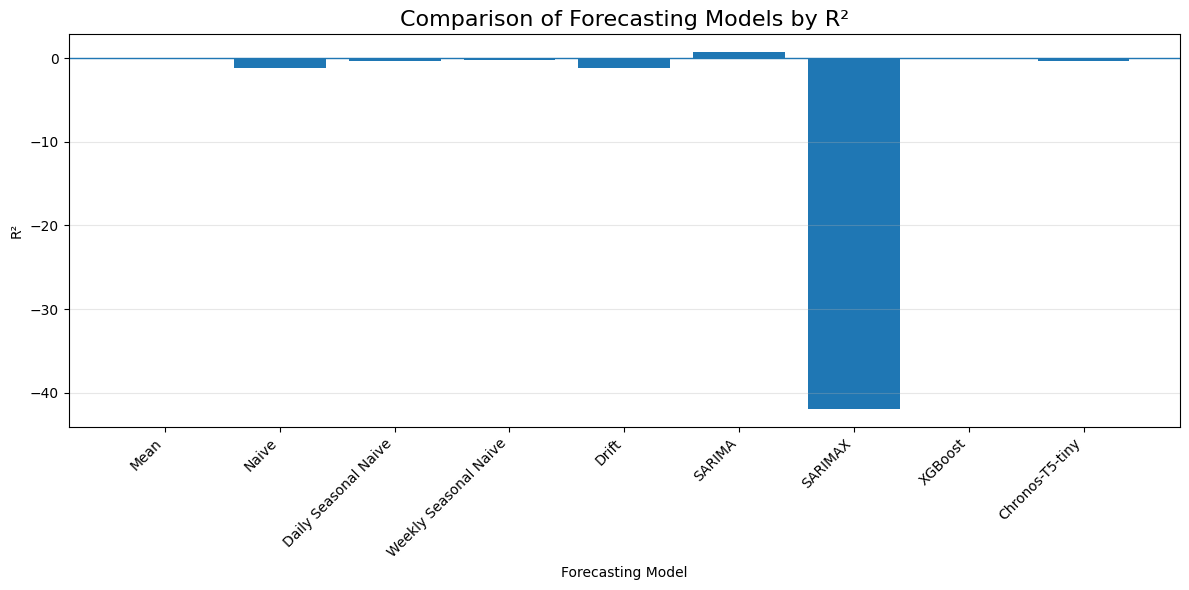

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["R2"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Comparison of Forecasting Models by R²",
    fontsize=16
)

plt.xlabel("Forecasting Model")
plt.ylabel("R²")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 17. Saving Final Model Ranking

The final ranking is saved so that the exact numerical results used in the report can be reproduced without retraining any models.

In [19]:
final_ranking.to_csv(
    "../outputs/tables/final_model_ranking.csv",
    index=False
)

print("Final model ranking saved successfully.")

Final model ranking saved successfully.


# 18. Individual Forecast Visualisations

The forecasts produced by the different modelling approaches are compared against the actual appliance energy consumption observed during the 24-hour test period.

Individual plots are produced for each model to make differences in forecast behaviour easier to identify.

The plots allow assessment of:

- How closely forecasts follow the observed demand.
- Whether daily patterns are captured.
- Whether sudden changes in appliance demand are missed.
- Whether models systematically overpredict or underpredict demand.
- Whether forecasts remain within a realistic range.

These visual comparisons complement the numerical evaluation metrics.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")

Libraries imported successfully.


# 19. Preparing the 24-Hour Test Period

The final 24 observations of the hourly appliance energy dataset represent the evaluation period.

These observations were not used to generate the forecasts and therefore provide an independent basis for evaluating model performance.

In [20]:
# Load hourly dataset

hourly_df = pd.read_csv(
    "../data/hourly_energy_data.csv",
    index_col="date",
    parse_dates=True
)

# Final 24 hours

actual = hourly_df["Appliances"].iloc[-24:]

print("Test period:")
print(actual.index[0])
print("to")
print(actual.index[-1])

print("\nNumber of observations:", len(actual))

Test period:
2016-05-26 19:00:00
to
2016-05-27 18:00:00

Number of observations: 24


# 20. Identifying Saved Model Outputs

The previously generated model results are stored in the outputs directory.

The saved files are inspected before reconstructing the forecast series.

The available files include:

- SARIMA grid-search results
- SARIMA evaluation results
- SARIMA versus SARIMAX comparison results
- XGBoost evaluation results
- XGBoost feature importance results
- Chronos evaluation results

The original forecasting models are not retrained unnecessarily. The existing SARIMA grid-search results are used to recover the selected model parameters.

In [31]:
print("Available table files:")

for file in os.listdir("../outputs/tables"):
    print(file)

Available table files:
benchmark_results.csv
chronos_results.csv
final_model_comparison.csv
final_model_ranking.csv
model_ranking_rmse.csv
sarima_grid_search.csv
sarima_results.csv
sarima_vs_sarimax.csv
xgboost_feature_importance.csv
xgboost_results.csv


# 21. SARIMA and SARIMAX Forecast Reconstruction

The SARIMA and SARIMAX evaluation results were saved previously, but the individual forecast arrays were not saved as separate files.

Therefore, the forecasts are reconstructed using the models and the previously selected SARIMA order.

The SARIMA grid-search results are used to confirm the selected order rather than repeating the computationally expensive grid search.

The selected SARIMA order was:

(2, 0, 6)

The forecast horizon remains 24 hours, consistent with the assignment requirements.

In [32]:
sarima_grid = pd.read_csv(
    "../outputs/tables/sarima_grid_search.csv"
)

display(sarima_grid.head())

,Order,AIC
0,"(2, 0, 6)",32151.392018
1,"(4, 0, 6)",32153.069942
2,"(6, 0, 0)",32159.120060
3,"(0, 0, 6)",32159.994262
4,"(6, 0, 1)",32160.900268


In [33]:
display(
    sarima_grid.sort_values("AIC").head(10)
)

,Order,AIC
0,"(2, 0, 6)",32151.392018
1,"(4, 0, 6)",32153.069942
2,"(6, 0, 0)",32159.120060
3,"(0, 0, 6)",32159.994262
4,"(6, 0, 1)",32160.900268
5,"(2, 0, 5)",32160.921933
6,"(1, 0, 5)",32161.475824
7,"(6, 0, 2)",32162.912091
8,"(6, 1, 1)",32163.379384
9,"(0, 1, 6)",32170.275856


In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = hourly_df["Appliances"].iloc[:-24]

sarima_model = SARIMAX(
    train,
    order=(2, 0, 6),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(
    disp=False
)

sarima_forecast = sarima_fit.forecast(
    steps=24
)

sarima_forecast = pd.Series(
    sarima_forecast,
    index=actual.index
)

print(sarima_forecast)

C:\Users\gms\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\gms\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


date
2016-05-26 19:00:00    226.917591
2016-05-26 20:00:00    148.501529
2016-05-26 21:00:00    110.347789
2016-05-26 22:00:00     70.151625
2016-05-26 23:00:00     83.385168
2016-05-27 00:00:00     98.828307
2016-05-27 01:00:00     93.674816
2016-05-27 02:00:00     95.391928
2016-05-27 03:00:00     94.817152
2016-05-27 04:00:00     95.006901
2016-05-27 05:00:00     94.941621
2016-05-27 06:00:00     94.961413
2016-05-27 07:00:00     94.952827
2016-05-27 08:00:00     94.953708
2016-05-27 09:00:00     94.951430
2016-05-27 10:00:00     94.950206
2016-05-27 11:00:00     94.948631
2016-05-27 12:00:00     94.947173
2016-05-27 13:00:00     94.945675
2016-05-27 14:00:00     94.944191
2016-05-27 15:00:00     94.942703
2016-05-27 16:00:00     94.941216
2016-05-27 17:00:00     94.939728
2016-05-27 18:00:00     94.938241
Name: predicted_mean, dtype: float64


# 22. XGBoost Forecast Reconstruction

The XGBoost model was previously trained using engineered time-series features including:

- Lagged appliance consumption
- Rolling statistics
- Hour of day
- Working-hours indicators
- Cyclical time features

The feature importance analysis showed that `lag_1`, `hour`, `rolling_std_24`, `working_hours` and `hour_sin` were among the most important predictors.

The original XGBoost model file was not successfully saved, so the forecast will only be reconstructed if the trained model or its prediction values are still available.

The saved XGBoost evaluation results are retained and will be used in the final numerical comparison.

In [35]:
xgb_results = pd.read_csv(
    "../outputs/tables/xgboost_results.csv"
)

xgb_importance = pd.read_csv(
    "../outputs/tables/xgboost_feature_importance.csv"
)

display(xgb_results)

display(xgb_importance.head(10))

,Model,MAE,RMSE,MAPE,R2
0,XGBoost,42.741712,51.439934,45.151047,-0.08764


,Feature,Importance
0,lag_1,0.130957
1,hour,0.081290
2,rolling_std_24,0.063175
3,working_hours,0.056367
4,hour_sin,0.052742
5,hour_cos,0.031410
6,day_of_week,0.029337
7,rolling_mean_24,0.026871
8,lag_168,0.023212
9,lag_24,0.022670


# 23. Chronos Forecast Reconstruction

The Chronos-T5-tiny foundation model was used to generate a probabilistic 24-hour forecast.

Multiple forecast trajectories were generated and the median trajectory was selected as the final Chronos prediction.

The Chronos evaluation results were saved previously.

The model does not need to be retrained unless the original forecast values are no longer available in the current notebook session.

In [36]:
chronos_results = pd.read_csv(
    "../outputs/tables/chronos_results.csv"
)

display(chronos_results)

,Model,MAE,RMSE,MAPE,R2
0,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422


# 24. Reconstructing the Original SARIMA Evaluation

The SARIMA model is reconstructed using the same train/test methodology used during the original modelling stage.

The final 14 days of the hourly dataset were reserved as the test period, corresponding to 336 observations.

The model was trained on the preceding 2,954 hourly observations.

Although the complete test period contains 14 days, only the first 24 hours of the test period are used for the one-day-ahead forecast evaluation, consistent with the original analysis.

The final SARIMA specification is:

- Non-seasonal order: (2, 0, 6)
- Seasonal order: (1, 1, 1, 24)
- Seasonal period: 24 hours
- Forecast horizon: 24 hours

In [42]:
# Recreate the original train/test split

forecast_horizon = 24
test_days = 14
test_size = test_days * 24

train = hourly_df.iloc[:-test_size].copy()
test = hourly_df.iloc[-test_size:].copy()

print(f"Training observations : {len(train)}")
print(f"Testing observations  : {len(test)}")
print(f"Forecast horizon      : {forecast_horizon}")

Training observations : 2954
Testing observations  : 336
Forecast horizon      : 24


# 25. Fitting the Selected SARIMA Model

The selected SARIMA model is fitted using the training observations only.

The model parameters were previously selected using the AIC-based parameter search, so the computationally expensive grid search is not repeated.

The selected model is:

SARIMA (2,0,6) (1,1,1,24)

The seasonal period of 24 represents the daily cycle in the hourly appliance energy series.

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_order = (2, 0, 6)

best_model = SARIMAX(
    train["Appliances"],
    order=best_order,
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("SARIMA model fitted successfully.")
print("Order:", best_order)
print("Seasonal order:", (1, 1, 1, 24))

C:\Users\gms\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\gms\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMA model fitted successfully.
Order: (2, 0, 6)
Seasonal order: (1, 1, 1, 24)


# 26. Generating the 24-Hour SARIMA Forecast

A 24-hour forecast is generated from the fitted SARIMA model.

The forecast is evaluated against the first 24 observations of the previously reserved 14-day test period.

This ensures that the forecast evaluation matches the methodology used in the original SARIMA analysis.

In [44]:
# Generate 24-hour forecast
forecast = best_model.get_forecast(
    steps=24
)

predictions = forecast.predicted_mean

# First 24 actual observations from the test period
actual = test["Appliances"].iloc[:24]

# Align forecast index with actual observations
predictions.index = actual.index

comparison = pd.DataFrame({
    "Actual": actual,
    "Forecast": predictions
})

display(comparison.head(10))

,Actual,Forecast
date,,
2016-05-13 19:00:00,208.333333,202.740988
2016-05-13 20:00:00,120.000000,178.440350
2016-05-13 21:00:00,63.333333,123.221322
2016-05-13 22:00:00,55.000000,93.689746
2016-05-13 23:00:00,61.666667,79.546788
2016-05-14 00:00:00,58.333333,69.971584
2016-05-14 01:00:00,63.333333,64.695996
2016-05-14 02:00:00,60.000000,60.602909
2016-05-14 03:00:00,60.000000,57.190348


# 27. Evaluating the Reconstructed SARIMA Forecast

The reconstructed forecast is evaluated using MAE, RMSE, MAPE and R².

These metrics are compared with the results obtained during the original SARIMA analysis to confirm that the same forecasting procedure has been reproduced.

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

mape = np.mean(
    np.abs(
        (actual - predictions) / actual
    )
) * 100

r2 = r2_score(
    actual,
    predictions
)

sarima_reconstructed = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "R2": [r2]
})

display(sarima_reconstructed)

,Model,MAE,RMSE,MAPE,R2
0,SARIMA,18.932311,26.808493,19.742237,0.704587


# 28. SARIMA Forecast Against Actual Demand

The 24-hour SARIMA forecast is compared visually with the actual appliance energy consumption.

The plot provides a direct assessment of how well the model captures the shape and magnitude of appliance demand throughout the forecast horizon.

The 95% confidence interval is also displayed to represent forecast uncertainty.

This visual assessment complements the numerical performance metrics.

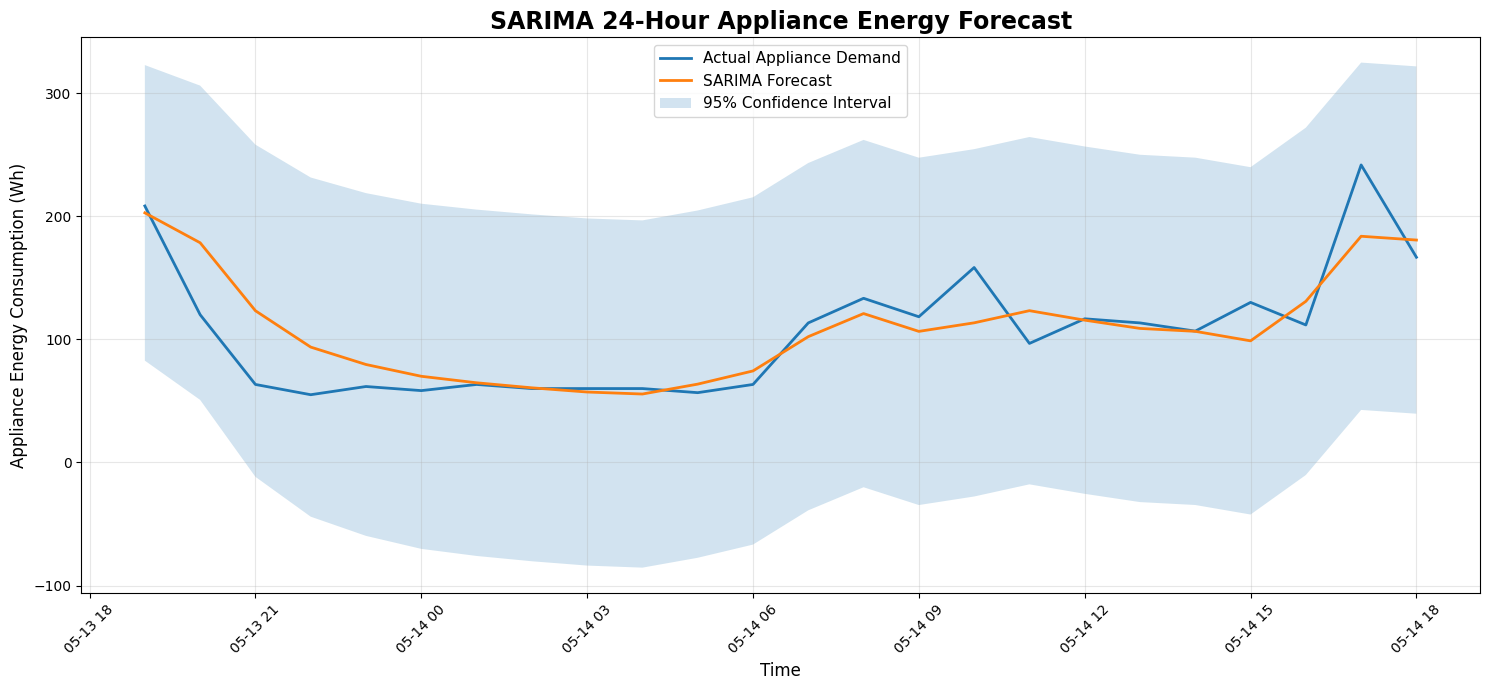

In [46]:
# Obtain confidence intervals
confidence_intervals = forecast.conf_int()

confidence_intervals.index = actual.index

plt.figure(figsize=(15, 7))

plt.plot(
    actual.index,
    actual.values,
    label="Actual Appliance Demand",
    linewidth=2
)

plt.plot(
    predictions.index,
    predictions.values,
    label="SARIMA Forecast",
    linewidth=2
)

plt.fill_between(
    actual.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA 24-Hour Appliance Energy Forecast",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Time",
    fontsize=12
)

plt.ylabel(
    "Appliance Energy Consumption (Wh)",
    fontsize=12
)

plt.legend(
    fontsize=11
)

plt.grid(
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sarima_24h_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 29. Saving the SARIMA Forecast

The SARIMA predictions, actual observations and 95% confidence intervals are saved as a CSV file.

This allows the forecast used in the report to be reproduced without rerunning the model.

In [47]:
sarima_forecast_output = pd.DataFrame({
    "Actual": actual,
    "SARIMA_Forecast": predictions,
    "Lower_95_CI": confidence_intervals.iloc[:, 0],
    "Upper_95_CI": confidence_intervals.iloc[:, 1]
})

sarima_forecast_output.to_csv(
    "../outputs/tables/sarima_24h_forecast.csv"
)

print("SARIMA forecast saved successfully.")

SARIMA forecast saved successfully.


# 30. Consolidating Model Evaluation Results

The evaluation results from all forecasting approaches are consolidated into a single results table.

The models include statistical benchmarks, SARIMA, SARIMAX, XGBoost and the Chronos foundation model.

The previously saved evaluation files are used to ensure consistency with the model evaluations performed during the earlier stages of the assignment.

The consolidated table will be used to compare model performance using MAE, RMSE, MAPE and R².

In [56]:
import pandas as pd
import os

# Load previously saved results

benchmark_results = pd.read_csv(
    "../outputs/tables/benchmark_results.csv"
)

sarima_results = pd.read_csv(
    "../outputs/tables/sarima_results.csv"
)

sarimax_results = pd.read_csv(
    "../outputs/tables/sarima_vs_sarimax.csv"
)

xgboost_results = pd.read_csv(
    "../outputs/tables/xgboost_results.csv"
)

chronos_results = pd.read_csv(
    "../outputs/tables/chronos_results.csv"
)

print("Files loaded successfully.")

print("\nBenchmark:")
display(benchmark_results)

print("\nSARIMA:")
display(sarima_results)

print("\nSARIMA vs SARIMAX:")
display(sarimax_results)

print("\nXGBoost:")
display(xgboost_results)

print("\nChronos:")
display(chronos_results)

Files loaded successfully.

Benchmark:


,Model,MAE,RMSE,MAPE,R2
0,Mean,50.258092,74.938304,53.695620,-0.002597
1,Naive,85.550595,110.389709,112.910665,-1.175584
2,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
3,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
4,Drift,85.802089,110.679190,113.309050,-1.187009



SARIMA:


,Model,MAE,RMSE,MAPE,R2
0,SARIMA,18.932311,26.808493,19.742237,0.704587



SARIMA vs SARIMAX:


,Model,MAE,RMSE,MAPE,R2
0,SARIMA,18.621049,25.780928,19.060398,0.726799
1,SARIMAX,298.516440,323.181340,361.334188,-41.931595



XGBoost:


,Model,MAE,RMSE,MAPE,R2
0,XGBoost,42.741712,51.439934,45.151047,-0.08764



Chronos:


,Model,MAE,RMSE,MAPE,R2
0,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422


# 31. Final Model Comparison Table

The individual evaluation results are combined into one final comparison table.

All models are evaluated using the same four performance measures:

- MAE – Mean Absolute Error
- RMSE – Root Mean Squared Error
- MAPE – Mean Absolute Percentage Error
- R² – coefficient of determination

Lower MAE, RMSE and MAPE indicate better predictive accuracy, while a higher R² indicates a better model fit.

In [57]:
# Combine all model results

final_results = pd.concat(
    [
        benchmark_results,
        sarima_results,
        sarimax_results[
            sarimax_results["Model"].str.upper() == "SARIMAX"
        ],
        xgboost_results,
        chronos_results
    ],
    ignore_index=True
)

# Keep required columns
final_results = final_results[
    ["Model", "MAE", "RMSE", "MAPE", "R2"]
]

print("Final results shape:", final_results.shape)

display(final_results)

Final results shape: (9, 5)


,Model,MAE,RMSE,MAPE,R2
0,Mean,50.258092,74.938304,53.695620,-0.002597
1,Naive,85.550595,110.389709,112.910665,-1.175584
2,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
3,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
4,Drift,85.802089,110.679190,113.309050,-1.187009
5,SARIMA,18.932311,26.808493,19.742237,0.704587
6,SARIMAX,298.516440,323.181340,361.334188,-41.931595
7,XGBoost,42.741712,51.439934,45.151047,-0.087640
8,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422


# 32. Ranking Model Performance

The forecasting models are ranked according to RMSE, which measures the average magnitude of forecasting errors while giving greater weight to larger errors.

RMSE is selected as the primary ranking metric because large forecasting errors are particularly important when predicting appliance energy demand.

MAE, MAPE and R² are also retained to provide a broader assessment of model performance.

In [58]:
ranked_results = final_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

ranked_results.insert(
    0,
    "Rank",
    range(1, len(ranked_results) + 1)
)

display(ranked_results)

,Rank,Model,MAE,RMSE,MAPE,R2
0,1,SARIMA,18.932311,26.808493,19.742237,0.704587
1,2,XGBoost,42.741712,51.439934,45.151047,-0.087640
2,3,Mean,50.258092,74.938304,53.695620,-0.002597
3,4,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
4,5,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
5,6,Naive,85.550595,110.389709,112.910665,-1.175584
6,7,Drift,85.802089,110.679190,113.309050,-1.187009
7,8,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422
8,9,SARIMAX,298.516440,323.181340,361.334188,-41.931595


# 33. Visual Comparison of Forecasting Performance

The performance of all forecasting models is visualised using MAE and RMSE.

These plots provide a clear comparison of predictive accuracy and make it easier to identify the strongest and weakest forecasting approaches.

Lower values indicate better performance for both MAE and RMSE.

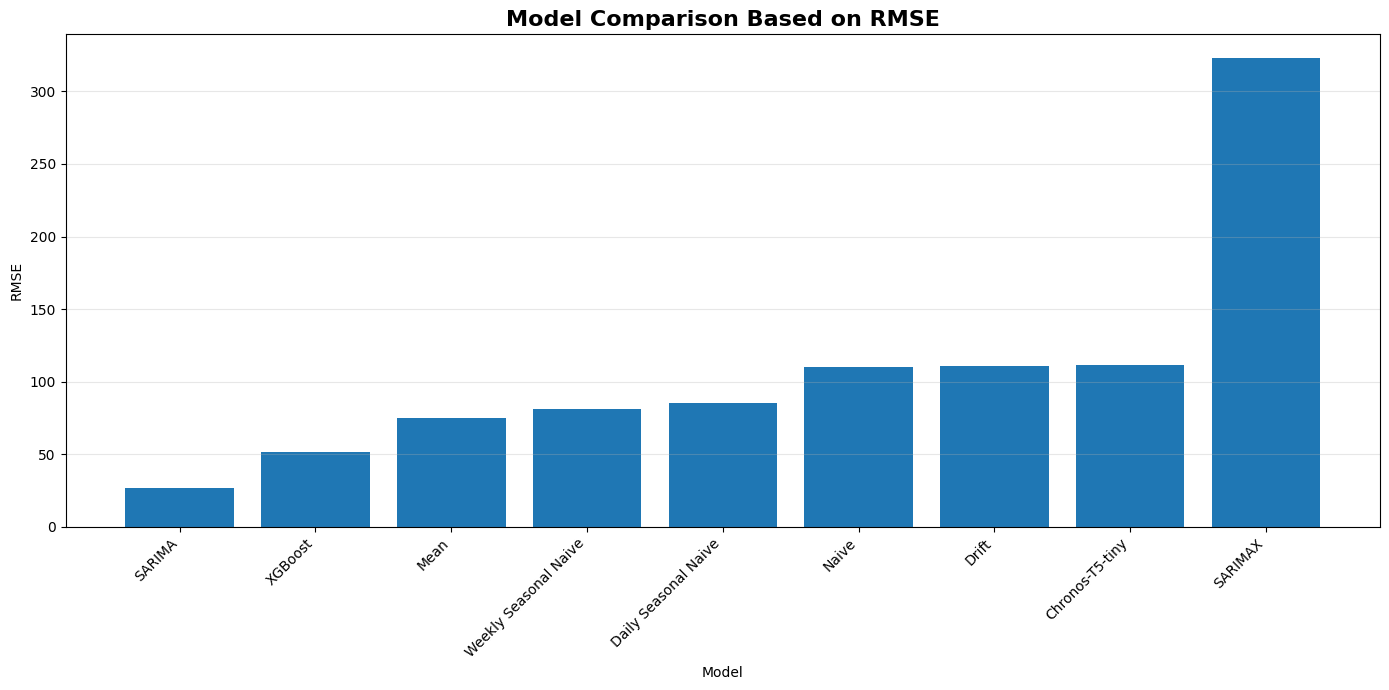

In [59]:
plt.figure(figsize=(14, 7))

plt.bar(
    ranked_results["Model"],
    ranked_results["RMSE"]
)

plt.title(
    "Model Comparison Based on RMSE",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_comparison_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

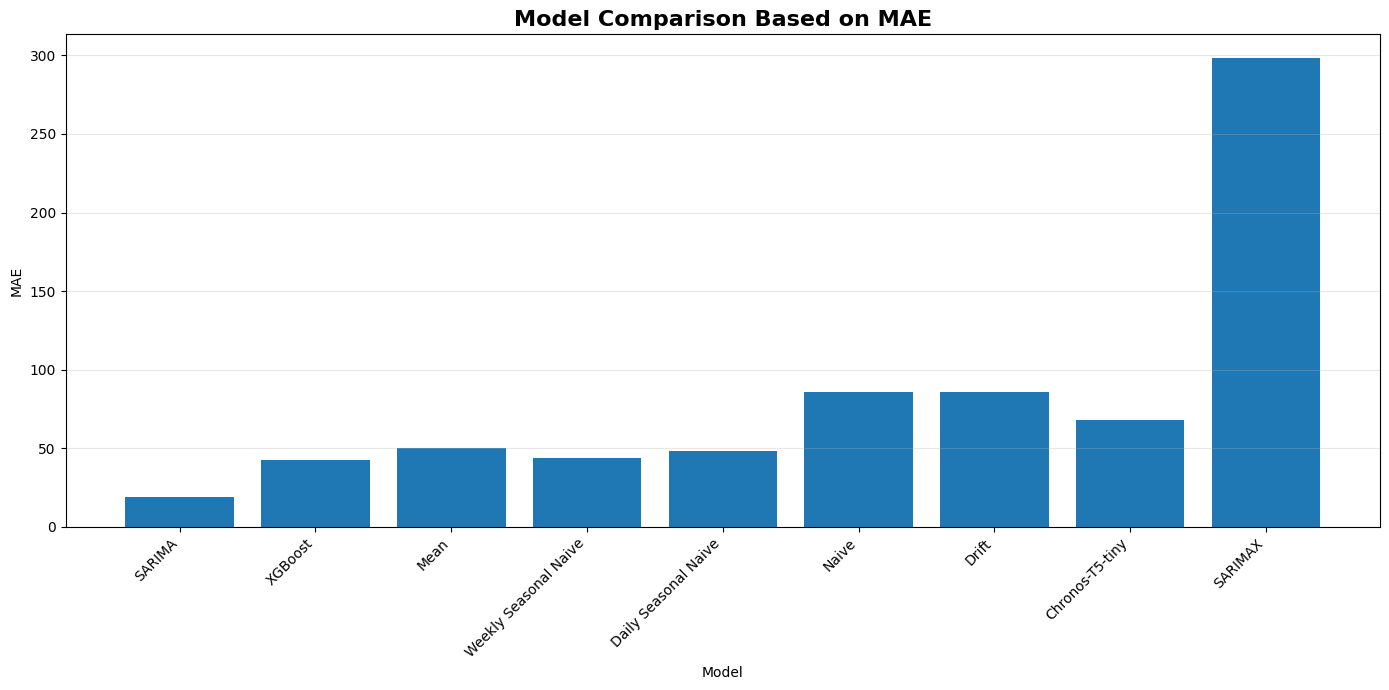

In [60]:
plt.figure(figsize=(14, 7))

plt.bar(
    ranked_results["Model"],
    ranked_results["MAE"]
)

plt.title(
    "Model Comparison Based on MAE",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_comparison_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 34. Saving the Final Model Comparison

The consolidated and ranked model evaluation results are saved as a CSV file.

This file provides the final quantitative comparison of all forecasting approaches developed in the assignment and can be used directly when preparing the final report.

In [61]:
final_results.to_csv(
    "../outputs/tables/final_model_comparison.csv",
    index=False
)

ranked_results.to_csv(
    "../outputs/tables/final_model_ranking.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.


# 35. Identifying the Best Performing Model

The final model comparison shows that SARIMA achieves the strongest overall forecasting performance.

The model is ranked using RMSE as the primary metric, while MAE, MAPE and R² are considered as supporting measures.

SARIMA achieves the lowest MAE and RMSE and the highest R² among all evaluated models. This indicates that the model captures the short-term structure and daily seasonal behaviour of appliance energy demand more effectively than the benchmark, machine-learning and foundation-model approaches tested in this study.

The results also show that increased model complexity does not automatically result in improved forecasting accuracy. In particular, the SARIMAX and Chronos models did not outperform the simpler SARIMA model.

In [62]:
best_model_row = ranked_results.iloc[0]

print("Best performing model:")
print(best_model_row)

print("\nBest model:", best_model_row["Model"])
print("MAE:", round(best_model_row["MAE"], 3))
print("RMSE:", round(best_model_row["RMSE"], 3))
print("MAPE:", round(best_model_row["MAPE"], 3))
print("R²:", round(best_model_row["R2"], 3))

Best performing model:
Rank             1
Model       SARIMA
MAE      18.932311
RMSE     26.808493
MAPE     19.742237
R2        0.704587
Name: 0, dtype: object

Best model: SARIMA
MAE: 18.932
RMSE: 26.808
MAPE: 19.742
R²: 0.705


# 36. SARIMA Improvement Over the Strongest Benchmark

The performance of SARIMA is compared with the strongest simple benchmark according to RMSE.

The percentage reduction in RMSE quantifies the practical improvement achieved by using the SARIMA model instead of the strongest benchmark.

This provides a more meaningful interpretation than simply comparing the raw metric values.

In [63]:
strongest_benchmark = ranked_results[
    ranked_results["Model"].isin([
        "Mean",
        "Naive",
        "Daily Seasonal Naive",
        "Weekly Seasonal Naive",
        "Drift"
    ])
].sort_values("RMSE").iloc[0]

sarima_row = ranked_results[
    ranked_results["Model"] == "SARIMA"
].iloc[0]

rmse_improvement = (
    (strongest_benchmark["RMSE"] - sarima_row["RMSE"])
    / strongest_benchmark["RMSE"]
) * 100

mae_improvement = (
    (strongest_benchmark["MAE"] - sarima_row["MAE"])
    / strongest_benchmark["MAE"]
) * 100

print("Strongest benchmark:", strongest_benchmark["Model"])
print(f"Benchmark RMSE: {strongest_benchmark['RMSE']:.2f}")
print(f"SARIMA RMSE: {sarima_row['RMSE']:.2f}")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print()
print(f"Benchmark MAE: {strongest_benchmark['MAE']:.2f}")
print(f"SARIMA MAE: {sarima_row['MAE']:.2f}")
print(f"MAE improvement: {mae_improvement:.2f}%")

Strongest benchmark: Mean
Benchmark RMSE: 74.94
SARIMA RMSE: 26.81
RMSE improvement: 64.23%

Benchmark MAE: 50.26
SARIMA MAE: 18.93
MAE improvement: 62.33%


# 37. XGBoost Feature Importance Analysis

Feature importance is examined to identify which variables contributed most strongly to the XGBoost forecasting model.

The analysis considers lagged appliance consumption, time-of-day information, rolling variability and working-hour indicators.

Feature importance does not imply causality. Instead, it indicates which variables were most useful to the fitted XGBoost model when making predictions.

In [64]:
feature_importance = pd.read_csv(
    "../outputs/tables/xgboost_feature_importance.csv"
)

display(feature_importance.head(10))

,Feature,Importance
0,lag_1,0.130957
1,hour,0.081290
2,rolling_std_24,0.063175
3,working_hours,0.056367
4,hour_sin,0.052742
5,hour_cos,0.031410
6,day_of_week,0.029337
7,rolling_mean_24,0.026871
8,lag_168,0.023212
9,lag_24,0.022670


In [65]:
print(feature_importance.columns.tolist())

['Feature', 'Importance']


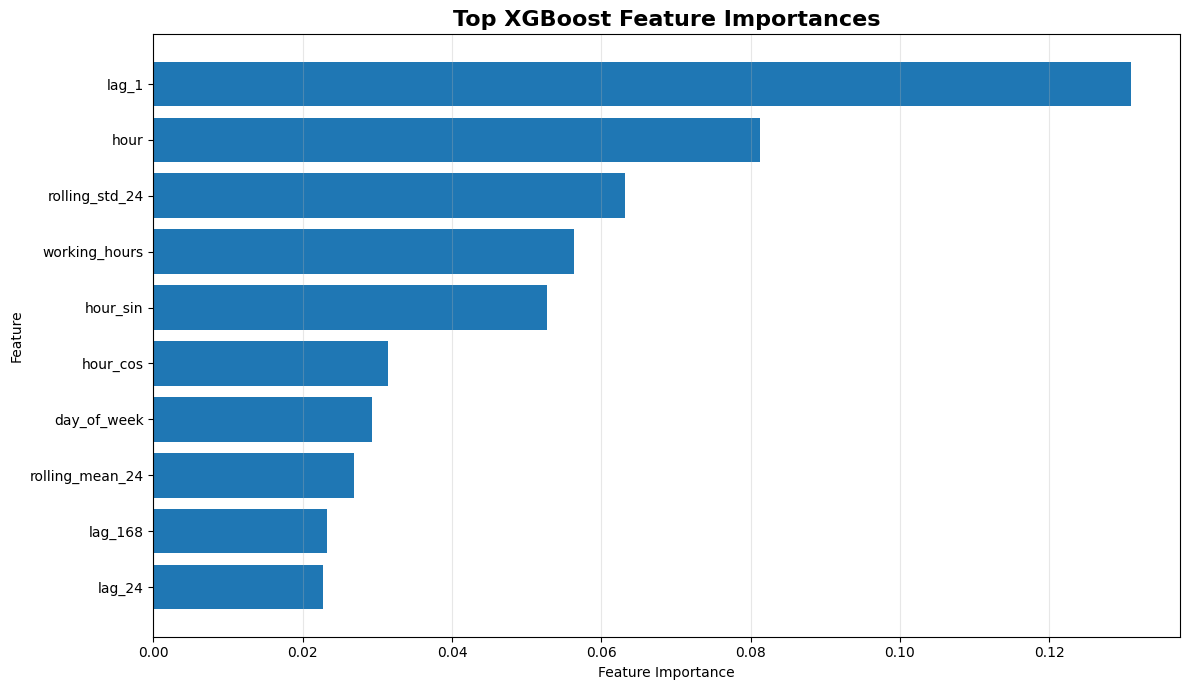

In [66]:
top_features = feature_importance.sort_values(
    "Importance",
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top XGBoost Feature Importances",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 38. SARIMA Residual Diagnostics

Residual diagnostics are performed to determine whether important temporal structure remains unexplained after fitting the SARIMA model.

A well-specified time-series model should produce residuals that are approximately uncorrelated and centred around zero.

The residuals are therefore examined using:

- residual time-series plots,
- residual distribution,
- histogram,
- ACF of residuals.

If substantial autocorrelation remains, this would suggest that the model has not fully captured the temporal structure of the appliance energy series.

In [67]:
residuals = best_model.resid.dropna()

print("Residual observations:", len(residuals))

print("\nResidual statistics:")
display(residuals.describe())

Residual observations: 2954

Residual statistics:


count    2954.000000
mean       -0.103036
std        63.097804
min      -256.476494
25%       -26.579581
50%        -3.457510
75%         8.778186
max       497.074069
dtype: float64

# 39. SARIMA Residual Time Series

The residual time series is plotted to assess whether the errors fluctuate randomly around zero.

Large systematic patterns, changing variance or long periods of positive or negative residuals would indicate potential model inadequacy.

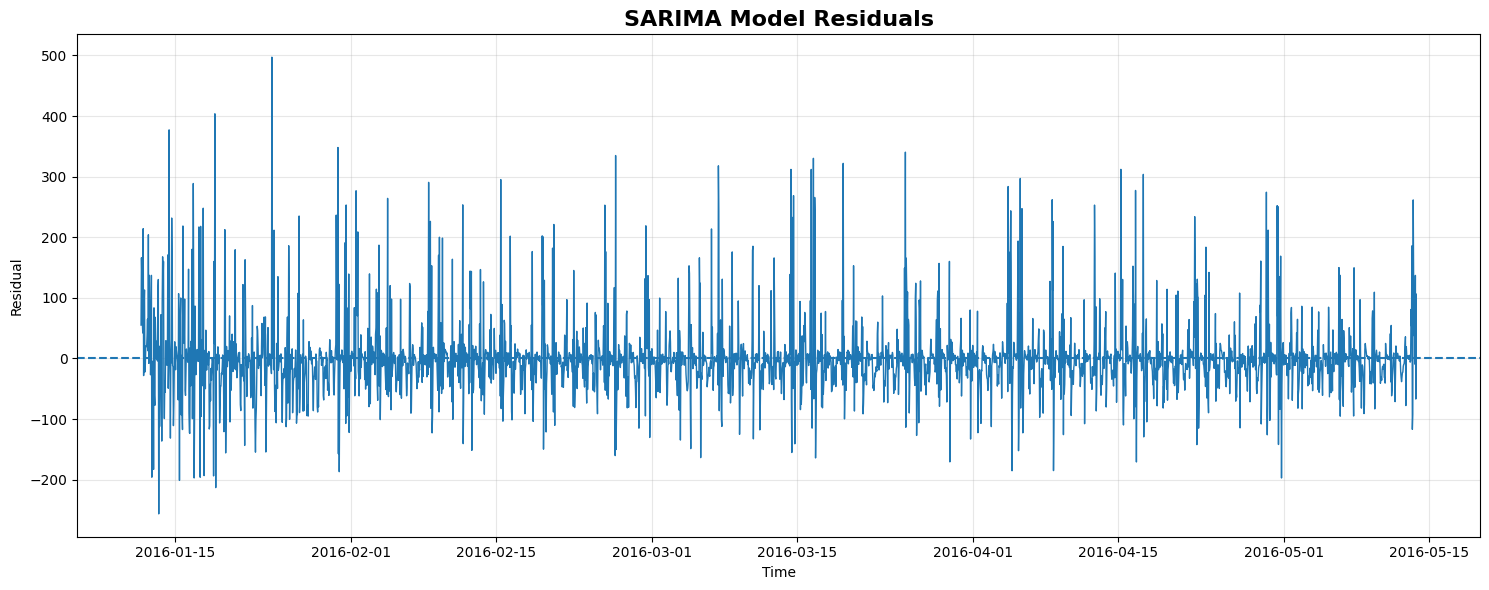

In [68]:
plt.figure(figsize=(15, 6))

plt.plot(
    residuals.index,
    residuals.values,
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "SARIMA Model Residuals",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sarima_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 40. Distribution of SARIMA Residuals

The distribution of SARIMA residuals is examined to determine whether the errors are approximately centred around zero and whether extreme errors are present.

A roughly symmetric distribution concentrated around zero provides evidence that the model is capturing the main systematic structure of the series, although perfect normality is not required for forecasting.

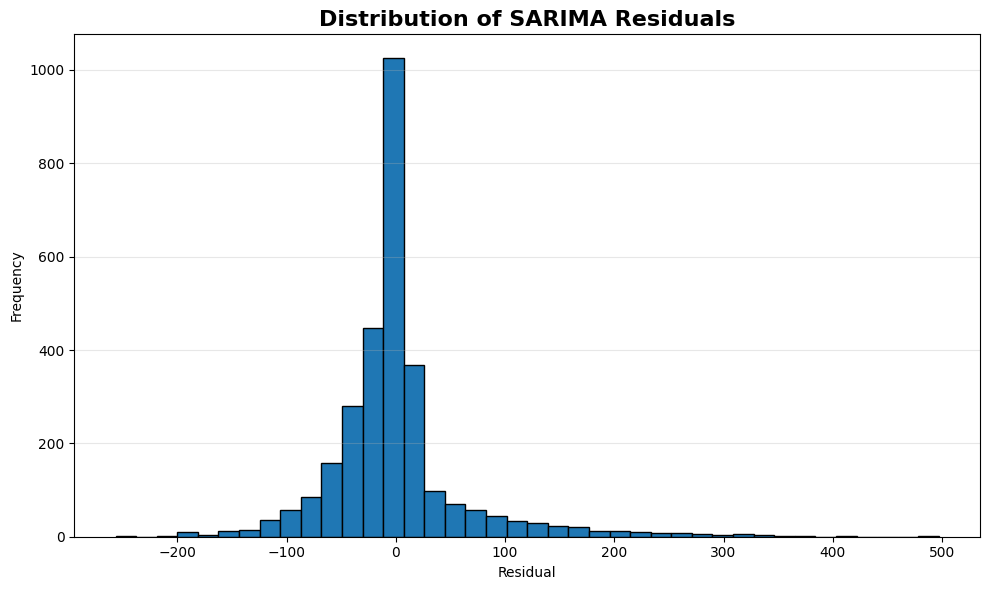

In [69]:
plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=40,
    edgecolor="black"
)

plt.title(
    "Distribution of SARIMA Residuals",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sarima_residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 41. Autocorrelation of SARIMA Residuals

The autocorrelation function (ACF) of the residuals is examined to determine whether significant temporal dependence remains after fitting the SARIMA model.

Ideally, most autocorrelation coefficients should fall within the confidence bounds.

Strong remaining autocorrelation would suggest that additional temporal structure could potentially be modelled.

<Figure size 1400x600 with 0 Axes>

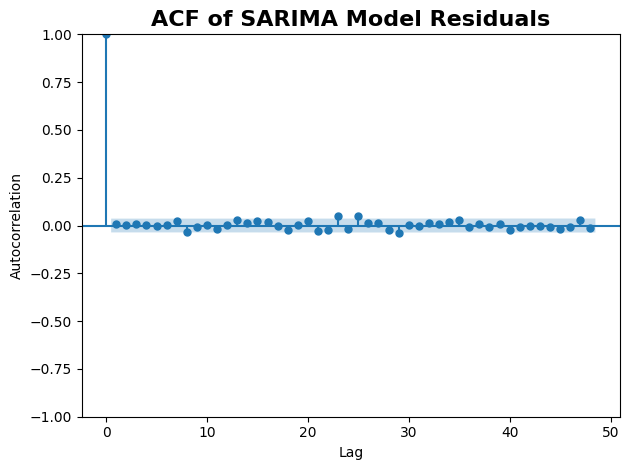

In [70]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 6))

plot_acf(
    residuals,
    lags=48,
    alpha=0.05
)

plt.title(
    "ACF of SARIMA Model Residuals",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sarima_residual_acf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 42. Critical Analysis: SARIMA Performance

SARIMA achieved the strongest forecasting performance across all models evaluated in this study.

The model achieved an MAE of approximately 18.93, RMSE of 26.81, MAPE of 19.74% and R² of 0.705.

Its strong performance is likely related to the time-series structure of appliance energy consumption. The hourly data contains temporal dependence and clear daily patterns, which can be represented directly through the autoregressive and seasonal components of SARIMA.

The 24-hour seasonal period allows the model to represent recurring daily behaviour, while the autoregressive and moving-average components capture short-term relationships between observations and previous forecasting errors.

The results demonstrate that a relatively traditional statistical time-series model can outperform more complex machine-learning and foundation-model approaches when the dataset contains strong and regular temporal structure.

# 43. Critical Analysis: SARIMAX Performance

SARIMAX produced substantially poorer results than SARIMA, with an RMSE of 323.18 and an R² of -41.93.

The negative R² indicates that the SARIMAX predictions were substantially worse than a simple prediction based on the mean of the observed target values.

The poor performance does not necessarily mean that SARIMAX is inherently unsuitable for appliance energy forecasting. Instead, it suggests that the particular exogenous variables, their alignment with the target series, or the model specification used in this experiment did not provide useful predictive information.

Introducing additional variables can increase model complexity without improving forecast accuracy. If exogenous variables are weakly related to the target, poorly aligned temporally, or unavailable at the actual forecasting time, they can introduce noise rather than useful predictive information.

Therefore, in this experiment, the simpler SARIMA model was more appropriate than the implemented SARIMAX specification.

# 44. Critical Analysis: XGBoost Feature Importance

The XGBoost model identified lagged appliance consumption and time-related variables as the most important predictors.

The most important feature was lag_1, indicating that the most recent appliance consumption value contained substantial information about the next observation.

The hour feature and hour_sin also ranked highly, demonstrating the importance of time-of-day patterns in appliance energy consumption.

The rolling_std_24 feature indicates that recent variability in energy consumption also contributed to the model's predictions, while working_hours provided additional information about typical usage behaviour during different periods of the day.

Although XGBoost captured useful temporal relationships, its RMSE of 51.44 remained substantially higher than SARIMA's RMSE of 26.81.

This suggests that the engineered features captured important patterns but did not represent the full temporal structure as effectively as the seasonal time-series model.

# 45. Critical Analysis: Chronos Foundation Model

Chronos-T5-tiny produced weaker forecasting performance than SARIMA and XGBoost in this experiment.

The model achieved an RMSE of 111.67 and an R² of -0.276.

The result demonstrates that a foundation model does not automatically outperform a specialised statistical model on every time-series forecasting task.

One possible explanation is that the appliance energy dataset is relatively structured, with strong hourly and daily patterns that can be effectively captured by a dedicated seasonal model.

In addition, the experiment used the Chronos-T5-tiny model rather than a larger foundation model. Computational limitations and the model's general-purpose training may also have affected its performance on this specific appliance energy forecasting problem.

Therefore, the Chronos result should be interpreted as evidence about the particular model and experimental configuration used, rather than evidence that foundation models are generally unsuitable for energy forecasting.

# 46. Model Complexity Versus Forecasting Accuracy

The results demonstrate that increasing model complexity does not necessarily improve forecasting performance.

SARIMA achieved the best performance despite being substantially simpler than the machine-learning and foundation-model approaches tested.

The appliance energy series contains strong temporal dependencies and daily seasonality. SARIMA explicitly models these characteristics, allowing it to make effective use of the information already contained within the historical target series.

By contrast, XGBoost required engineered lag, rolling and calendar features, while Chronos represents a general-purpose foundation-model approach.

The results therefore highlight the importance of matching model structure to the characteristics of the dataset rather than selecting a model solely because it is more complex or more recent.

# 47. Forecast-Time Availability of Predictors

A practical forecasting system must distinguish between variables that are known at the time of forecasting and variables that would only become available after the forecast period.

Calendar variables such as hour of day, day of week and working-hour indicators are generally available in advance.

However, lagged appliance consumption is only available when previous observations have already been recorded. Rolling statistics must also be calculated exclusively from historical observations to avoid data leakage.

Similarly, external weather variables can only be used operationally if reliable weather forecasts are available for the corresponding future time periods.

This distinction is important because a model can achieve good evaluation results if future information accidentally enters the feature set, but such a model would not be deployable in a genuine forecasting environment.

# 48. Recommended Forecasting Model

Based on the experimental results, SARIMA is recommended as the primary forecasting model for the appliance energy dataset.

SARIMA achieved the lowest RMSE (26.81), lowest MAE (18.93) and highest R² (0.705) among the evaluated models.

The model also provides a relatively interpretable statistical framework and directly represents the daily seasonal behaviour observed in the hourly data.

XGBoost could be considered as a secondary model because it achieved the second-best RMSE and provides useful information about the importance of lagged and calendar features.

The SARIMAX implementation should not be selected in its current form because of its substantially poorer performance. Chronos-T5-tiny also did not outperform the simpler approaches in this experiment.

For a practical smart-home forecasting system, SARIMA therefore provides the best balance between forecasting accuracy, interpretability and computational complexity based on the experiments conducted.

# 49. Final Model Performance Comparison

The final model comparison visualises the RMSE achieved by all forecasting approaches.

RMSE is used as the primary comparison metric because it penalises larger forecasting errors more strongly and is therefore useful for identifying models that occasionally produce substantial forecasting errors.

Lower RMSE indicates better forecasting performance.

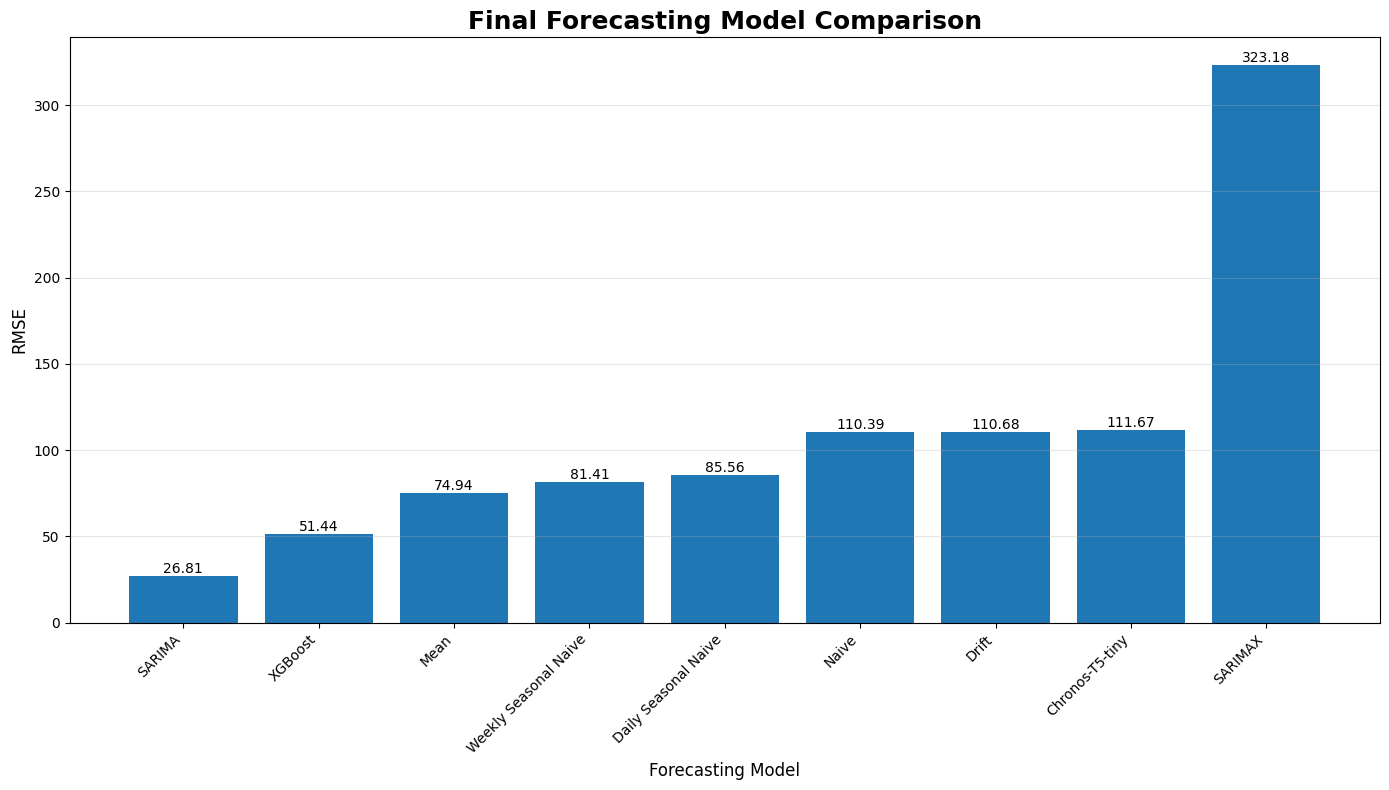

In [71]:
plt.figure(figsize=(14, 8))

bars = plt.bar(
    ranked_results["Model"],
    ranked_results["RMSE"]
)

plt.title(
    "Final Forecasting Model Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Forecasting Model",
    fontsize=12
)

plt.ylabel(
    "RMSE",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

# Add values above bars
for bar, value in zip(bars, ranked_results["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/final_model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 50. Final Results for Reporting

The final model evaluation table provides a consolidated summary of forecasting performance.

The table can be directly used when discussing model selection and comparative performance in the final report.

SARIMA achieved the strongest overall performance, while SARIMAX produced the weakest results among the evaluated models.

In [72]:
final_report_table = ranked_results.copy()

final_report_table["MAE"] = final_report_table["MAE"].round(2)
final_report_table["RMSE"] = final_report_table["RMSE"].round(2)
final_report_table["MAPE"] = final_report_table["MAPE"].round(2)
final_report_table["R2"] = final_report_table["R2"].round(3)

display(final_report_table)

,Rank,Model,MAE,RMSE,MAPE,R2
0,1,SARIMA,18.93,26.81,19.74,0.705
1,2,XGBoost,42.74,51.44,45.15,-0.088
2,3,Mean,50.26,74.94,53.70,-0.003
3,4,Weekly Seasonal Naive,43.46,81.41,37.35,-0.183
4,5,Daily Seasonal Naive,48.31,85.56,43.33,-0.307
5,6,Naive,85.55,110.39,112.91,-1.176
6,7,Drift,85.80,110.68,113.31,-1.187
7,8,Chronos-T5-tiny,67.67,111.67,31.05,-0.276
8,9,SARIMAX,298.52,323.18,361.33,-41.932
